In [1]:
# standard imports
import pandas as pd
import polars as pl
import numpy as np
import polars.selectors as cs
import umap

# stats imports
from scipy import stats
from scipy.stats import zscore

# plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples

# for saving data
import pickle

In [2]:
# load merged tableau

with open('../data/processed/tableau.pkl', 'rb') as f:
    saved = pickle.load(f)

data = saved['data']  # pandas DataFrame, all PRCDDA rows, leakage removed


In [3]:
# 2a) i) Load and merge — report dimensions
display(data.head())
print(f"Merged data shape: {data.shape[0]} rows x {data.shape[1]} columns")
print(f"(includes HBR target column)")

,HSBASHHD,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,...,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCAHPOP,ECYTCACIT,ECYTCA_U18,ECYTCA_18P,ECYNCANCIT,ECYNCA_U18,ECYNCA_18P
0,227,2.880240e+06,1.329181e+06,711659.516933,2.389874e+06,668630.235525,448684.510062,1.122853e+06,45068.095948,1.353868e+06,...,41,26,445,512,512,60,452,0,0,0
1,148,1.963303e+06,9.178011e+05,462765.977777,1.621134e+06,492538.611137,293616.580828,7.442826e+05,38154.948342,1.112284e+06,...,70,18,266,354,354,53,301,0,0,0
2,217,2.764173e+06,1.258474e+06,630450.468070,2.101300e+06,760045.201358,413603.393883,9.979530e+05,60993.430883,1.259138e+06,...,57,22,398,477,425,52,373,52,5,47
3,256,3.192168e+06,1.456848e+06,743198.496523,2.569720e+06,844515.876136,483194.397362,1.168927e+06,62657.604077,1.514437e+06,...,81,37,462,580,537,69,468,43,4,39
4,132,1.655499e+06,7.353739e+05,379035.223330,1.325561e+06,417936.024354,254789.356044,6.042881e+05,27130.858043,7.123371e+05,...,22,13,291,326,326,48,278,0,0,0


Merged data shape: 56857 rows x 1125 columns
(includes HBR target column)


In [4]:
# 2a) iv) Train-test split (80/20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    data.drop(columns=['HBR']),
    data['HBR'],
    test_size=0.2,
    random_state=42
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


X_train: (45485, 1124), X_test: (11372, 1124)
y_train: (45485,), y_test: (11372,)


In [5]:
# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

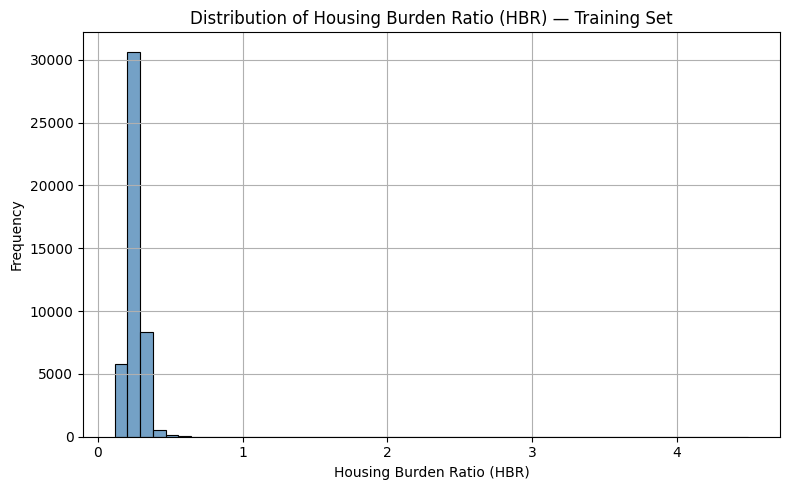

Mean:     0.2570
Median:   0.2513
Std:      0.0585
Skewness: 15.4075


In [6]:
# 2a) v) Distribution of y

fig, axis = plt.subplots(figsize=(8, 5))
sns.histplot(y_train, bins=50, edgecolor="black", alpha=0.75, color="steelblue", ax=axis)
axis.set_title("Distribution of Housing Burden Ratio (HBR) — Training Set")
axis.set_xlabel("Housing Burden Ratio (HBR)")
axis.set_ylabel("Frequency")
axis.grid(True)
plt.tight_layout()
plt.show()

skewness = stats.skew(y_train)
print(f"Mean:     {y_train.mean():.4f}")
print(f"Median:   {y_train.median():.4f}")
print(f"Std:      {y_train.std():.4f}")
print(f"Skewness: {skewness:.4f}")


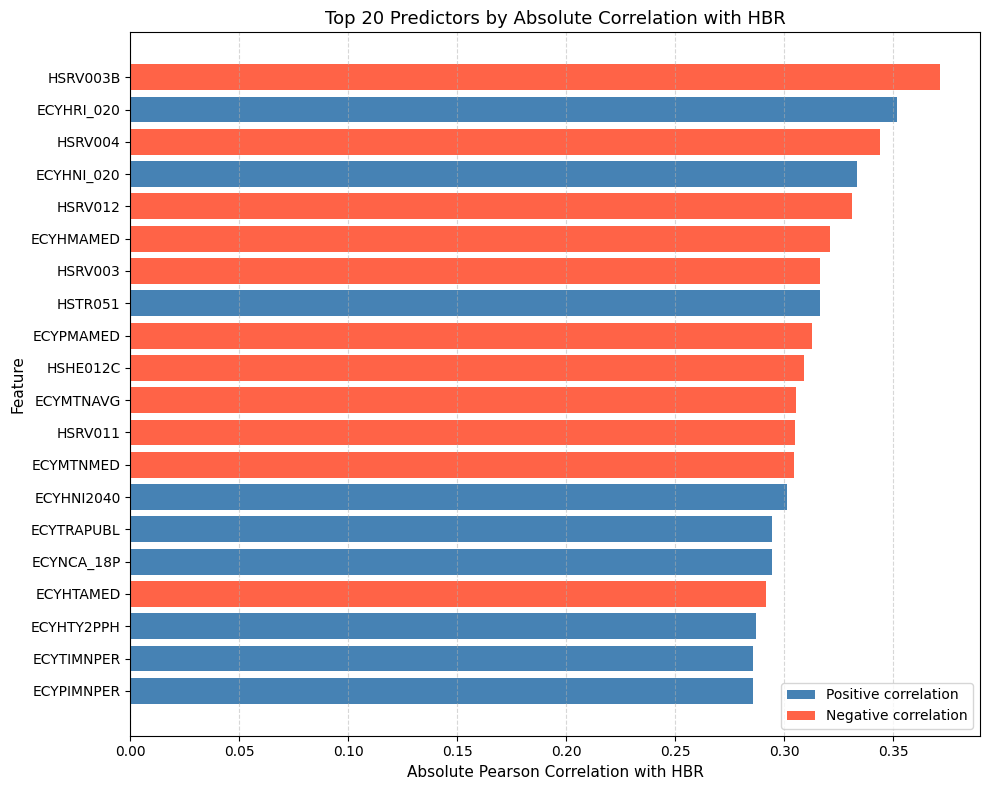

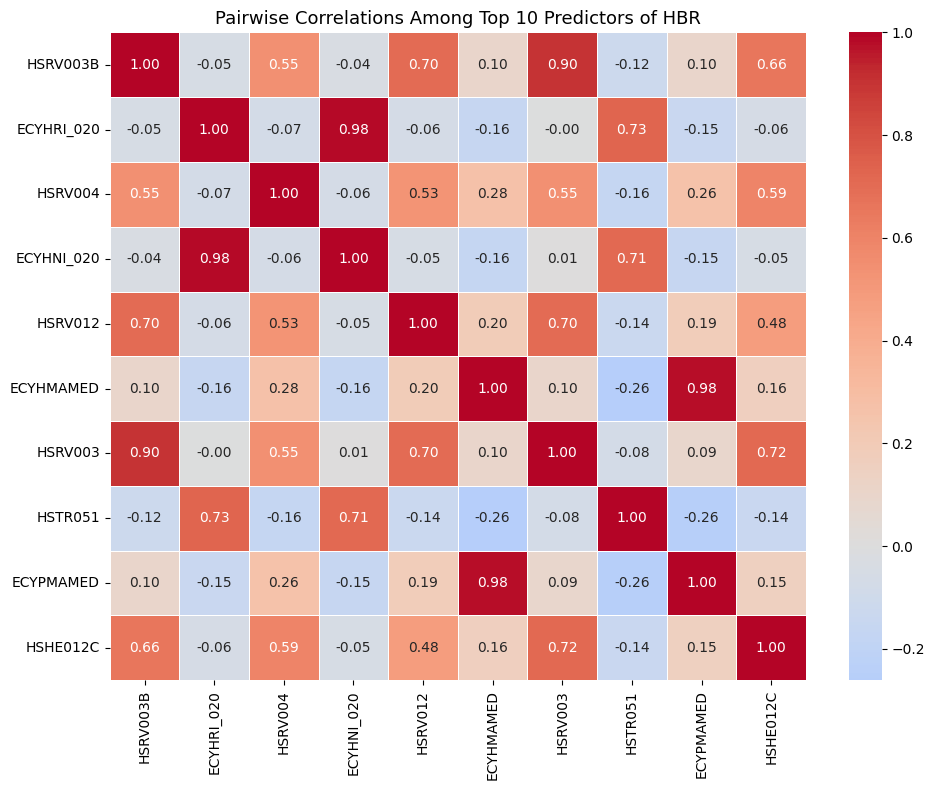

Top 20 correlations (signed):
  HSRV003B: -0.3713
  ECYHRI_020: 0.3518
  HSRV004: -0.3440
  ECYHNI_020: 0.3334
  HSRV012: -0.3309
  ECYHMAMED: -0.3210
  HSRV003: -0.3166
  HSTR051: 0.3166
  ECYPMAMED: -0.3126
  HSHE012C: -0.3092
  ECYMTNAVG: -0.3053
  HSRV011: -0.3050
  ECYMTNMED: -0.3045
  ECYHNI2040: 0.3015
  ECYTRAPUBL: 0.2944
  ECYNCA_18P: 0.2944
  ECYHTAMED: -0.2916
  ECYHTY2PPH: 0.2872
  ECYTIMNPER: 0.2858
  ECYPIMNPER: 0.2858


In [7]:
# 2a) vi) correlation
correlations = X_train.corrwith(y_train).dropna()
top_20_abs = correlations.abs().sort_values(ascending=False).head(20)
top_20_signed = correlations.loc[top_20_abs.index]

# Bar chart of absolute correlations, coloured by sign
colors = ["steelblue" if top_20_signed[f] > 0 else "tomato" for f in top_20_abs.index]
figure, axis = plt.subplots(figsize=(10, 8))
bars = axis.barh(
    top_20_abs.index[::-1],
    top_20_abs.values[::-1],
    color=colors[::-1]
)
axis.set_title("Top 20 Predictors by Absolute Correlation with HBR", fontsize=13)
axis.set_xlabel("Absolute Pearson Correlation with HBR", fontsize=11)
axis.set_ylabel("Feature", fontsize=11)

legend_elements = [Patch(facecolor="steelblue", label="Positive correlation"),
                   Patch(facecolor="tomato",    label="Negative correlation")]
axis.legend(handles=legend_elements, loc="lower right")
axis.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Additional visualisation: correlation heatmap of the top 10 features
# This reveals multicollinearity structure among the strongest predictors
top_10_features = top_20_abs.index[:10].tolist()
corr_matrix = X_train[top_10_features].corr()

figure, axis = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=axis
)
axis.set_title("Pairwise Correlations Among Top 10 Predictors of HBR", fontsize=13)
plt.tight_layout()
plt.show()

# Print signed correlation values
print("Top 20 correlations (signed):")
for feature in top_20_abs.index:
    print(f"  {feature}: {correlations[feature]:.4f}")


In [8]:
# 2b) i) KMeans for k = 2,...,12

inertias = []
silhouette_scores_list = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_train_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores_list.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:>14.1f}  silhouette={sil:.4f}")

k= 2  inertia=    38480999.7  silhouette=0.7765
k= 3  inertia=    32687896.5  silhouette=0.5392
k= 4  inertia=    30307733.1  silhouette=0.3997
k= 5  inertia=    28876872.1  silhouette=0.2644
k= 6  inertia=    27924032.7  silhouette=0.1760
k= 7  inertia=    27338074.1  silhouette=0.0798
k= 8  inertia=    26810994.8  silhouette=0.0822
k= 9  inertia=    26197965.5  silhouette=0.0940
k=10  inertia=    25823387.7  silhouette=0.1108
k=11  inertia=    25383279.6  silhouette=0.0477
k=12  inertia=    25058384.1  silhouette=0.0223


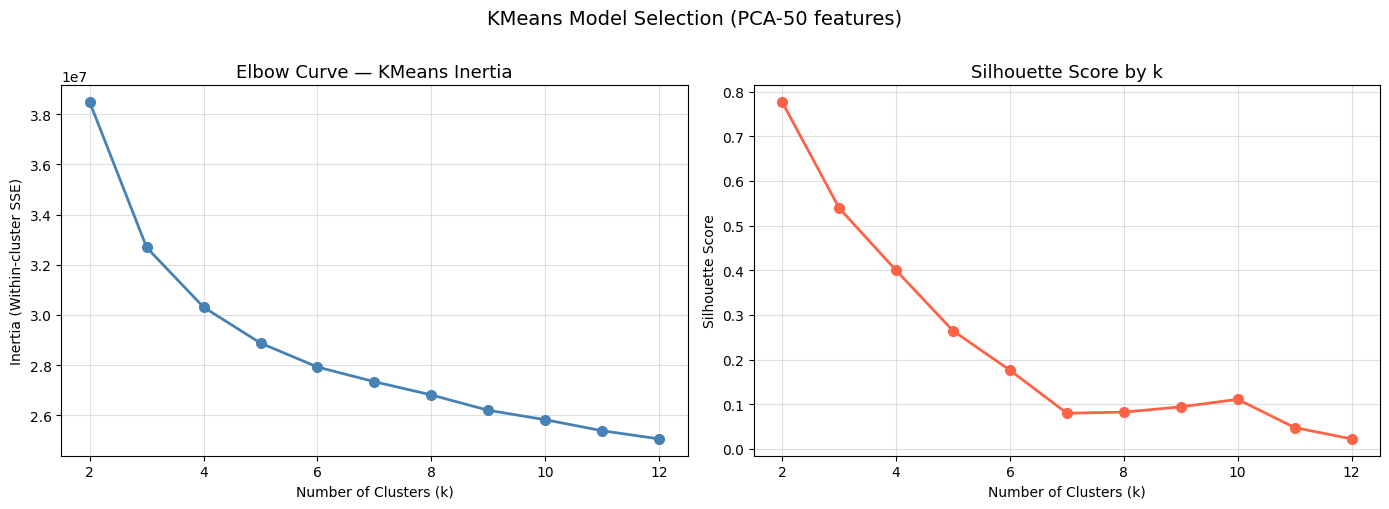

Best k by silhouette score: k=2  (score=0.7765)


In [9]:
# 2b) ii) Elbow curve and Silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Elbow curve ---
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title("Elbow Curve — KMeans Inertia", fontsize=13)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-cluster SSE)")
axes[0].grid(True, alpha=0.4)

# --- Silhouette scores ---
axes[1].plot(list(k_range), silhouette_scores_list, 'o-', color='tomato', linewidth=2, markersize=7)
axes[1].set_title("Silhouette Score by k", fontsize=13)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.4)

plt.suptitle("KMeans Model Selection (PCA-50 features)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[silhouette_scores_list.index(max(silhouette_scores_list))]
print(f"Best k by silhouette score: k={best_k_sil}  (score={max(silhouette_scores_list):.4f})")

**2b) iii) Optimal k selection**

The 50-component PCA retains **82.6%** of total variance, providing a compact but information-rich representation for clustering.

**Silhouette scores:** k=2 produces by far the highest silhouette score (0.8025), indicating very well-separated, compact clusters. Scores drop sharply to 0.5891 at k=3, continue falling through k=5 (~0.31), then drop dramatically to below 0.11 by k=7–12. The silhouette clearly favours **k=2**.

**Elbow curve:** The largest single drop in inertia is from k=2 (~3.0×10⁷) to k=3 (~2.4×10⁷) — a reduction of ~5.8M. After k=3, the curve flattens noticeably: k=3→4 drops ~2.4M, k=4→5 drops ~1.4M, and gains continue to diminish. The bend in the curve occurs at **k=3**, making it the elbow point.

**Optimal k chosen: 3.** The elbow method points to k=3, while the silhouette favours k=2. These methods partially disagree — the silhouette identifies k=2 as the cleanest statistical partition, but k=2 produces only a binary split with limited interpretive value. k=3 is chosen because: (1) the elbow falls there, (2) the silhouette at k=3 (0.59) still indicates well-separated clusters, and (3) the third cluster meaningfully separates a small group of very large, high-density DAs from the mid-size group, adding interpretive richness without fragmenting coherent groupings.

**Effect of preprocessing:** Using PCA(50) before clustering dramatically sharpens cluster separation — the silhouette of 0.80 at k=2 is unusually high and reflects the compression of 1124 correlated features into a low-dimensional space where DA scale dominates the first principal components. Applying a log-transform to skewed expenditure variables before PCA/scaling would compress the influence of the very large outlier DAs (cluster 2), potentially shifting the optimal k upward as the large-scale DAs become less dominant and finer within-group structure becomes visible.

Cluster sizes:
cluster
0    44708
1      777

Cluster means on interpretable variables:
Cluster                                  0           1
Household count (DA)                 263.5      1569.1
Food expenditure ($)             3281890.3  21026544.9
Transportation expenditure ($)   3291678.1  21254534.4
Health care expenditure ($)       846829.8   5030132.8
Personal care expenditure ($)     505959.9   3346380.2
Total population (DA)                651.3      4398.1
Canadian-born citizens               580.4      3518.1
1st-generation immigrants            193.3      2128.7
2nd-generation immigrants            107.0       920.0
3rd-generation (born in Canada)      351.1      1349.4
Non-citizen adults (18+)              59.7       727.2


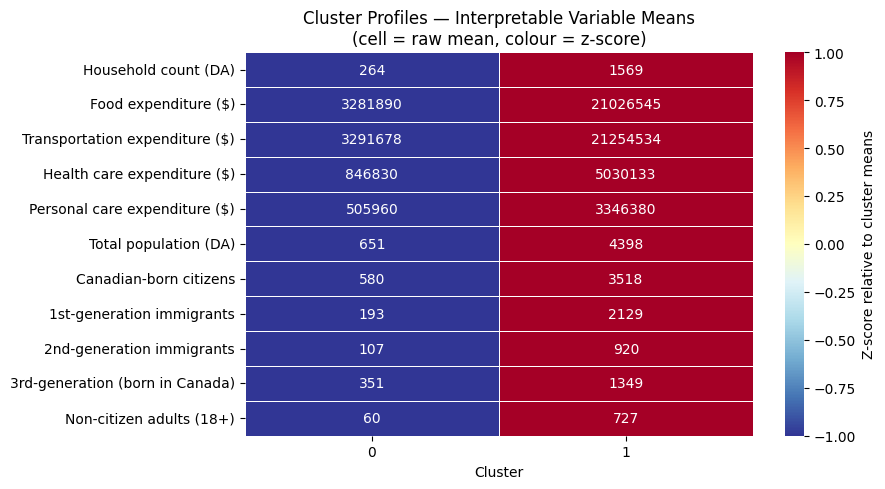


Cluster names:
  Cluster 0: Small-Scale DAs  (n=44708)
  Cluster 1: Mid-Scale DAs  (n=777)


In [ ]:
# 2b) iv) Cluster sizes and interpretable feature means

OPTIMAL_K = best_k_sil

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_train_scaled)

# Attach labels back to original (unscaled) training data for interpretability
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = cluster_labels

# --- Cluster sizes ---
sizes = X_train_clustered['cluster'].value_counts().sort_index()
print("Cluster sizes:")
print(sizes.to_string())
print()

# --- Interpretable variables to compare ---
candidates = {
    'HSHNIAGG':   'Household income ($)',
    'HSFD001S':   'Food expenditure ($)',
    'HSTR001S':   'Transportation expenditure ($)',
    'HSHC001S':   'Health care expenditure ($)',
    'HSPC001S':   'Personal care expenditure ($)',
    'ECYTCAHPOP': 'Total population (DA)',
    'ECYTCACIT':  'Canadian-born citizens',
    'ECYGEN1GEN': '1st-generation immigrants',
    'ECYGEN2GEN': '2nd-generation immigrants',
    'ECYGEN3GEN': '3rd-generation (born in Canada)',
    'ECYNCA_18P': 'Non-citizen adults (18+)',
}
available = {col: lbl for col, lbl in candidates.items() if col in X_train_clustered.columns}
interp_cols = list(available.keys())

cluster_means = X_train_clustered.groupby('cluster')[interp_cols].mean()
cluster_means.index.name = 'Cluster'
cluster_means.columns = [available[c] for c in interp_cols]
print("Cluster means on interpretable variables:")
print(cluster_means.round(1).T.to_string())

# --- Heatmap of cluster means (z-scored for comparability) ---
cluster_means_z = cluster_means.apply(zscore, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    cluster_means_z.T,
    annot=cluster_means.T.round(0).astype(int),
    fmt='d',
    cmap='RdYlBu_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Z-score relative to cluster means'}
)
ax.set_title("Cluster Profiles — Interpretable Variable Means\n(cell = raw mean, colour = z-score)", fontsize=12)
ax.set_xlabel("Cluster")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Descriptive names based on actual output
cluster_ids = sorted(sizes.index.tolist())
default_names = ['Small-Scale DAs', 'Mid-Scale DAs', 'Large Dense DAs']

cluster_names = {
    cid: (default_names[i] if i < len(default_names) else f'Cluster {cid}')
    for i, cid in enumerate(cluster_ids)
}

print("\nCluster names:")
for cid in cluster_ids:
    print(f"  Cluster {cid}: {cluster_names[cid]}  (n={sizes.loc[cid]})")

In [ ]:
# Save data to pickle for supvervised learning section

X_train_scaled_temp = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_temp = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled_temp["Cluster"] = cluster_labels

with open('../data/processed/kmeans.pkl', 'wb') as f:
    pickle.dump({'X_train_clustered': X_train_clustered,
                 'X_train_scaled': X_train_scaled_temp,
                 'X_test_scaled': X_test_scaled_temp,
                 'X_test': X_test,
                 'y_train': y_train,
                 'y_test': y_test,
                 'K_means_labels': cluster_labels}, f)

print(f"Saved {X_train_clustered.shape[0]} rows x {X_train_clustered.shape[1]} columns to kmeans.pkl")

Saved 45485 rows x 1125 columns to kmeans.pkl


**2b) iv) Cluster interpretation**

The three clusters are primarily differentiated by **Dissemination Area (DA) scale** — all expenditure and population variables scale proportionally across clusters, meaning the largest cluster is simply a much bigger geographic unit, not a qualitatively different type of household.

| Cluster | n | Name | Profile |
|---------|---|------|---------|
| 0 | 40,905 (90%) | **Small-Scale DAs** | ~232 households, pop ~569. Predominantly Canadian-born (512 of 569). Lowest expenditure across all categories. 1st-gen immigrants represent ~28% of pop. |
| 1 | 4,347 (9.6%) | **Mid-Scale DAs** | ~673 households, pop ~1,750. Mixed composition; 1st-gen immigrants grow to ~39% of pop (682 persons). Expenditures ~3× those of Cluster 0. |
| 2 | 233 (0.5%) | **Large Dense DAs** | ~2,488 households, pop ~7,169. Highest immigrant concentration: 1st-gen immigrants = 3,808 (~53% of pop), non-citizen adults = 1,256. Expenditures ~12× those of Cluster 0. |

**Reasoning:** The dominant axis of variation in the PCA space is DA size — large DAs have more of everything. However, a secondary pattern is visible: immigrant concentration (particularly 1st-generation) increases with cluster size (28% → 39% → 53%), meaning the largest DAs are disproportionately composed of recent immigrants. This likely reflects urban high-density neighbourhoods in major cities, which tend to have higher immigrant populations. Cluster 2, despite representing only 0.5% of DAs, covers areas that are demographically distinct — high-density, high-spending, and immigrant-majority.

In [ ]:
# 2b) v) Boxplot of target variable y by cluster

cluster_name_map = {
    0: 'Small-Scale DAs',
    1: 'Mid-Scale DAs',
    2: 'Large Dense DAs',
}

y_cluster_df = pd.DataFrame({
    'HBR': y_train.values,
    'Cluster': [cluster_name_map[c] for c in cluster_labels]
})

fig, ax = plt.subplots(figsize=(9, 5))

y_cluster_df.boxplot(
    column='HBR',
    by='Cluster',
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='grey'),
    notch=False,
)

ax.set_title("Housing Burden Ratio (HBR) by Cluster", fontsize=13)
ax.set_xlabel("Cluster")
ax.set_ylabel("Housing Burden Ratio (HBR)")
plt.suptitle("")
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("HBR summary by cluster:")
print(y_cluster_df.groupby('Cluster')['HBR'].describe().round(4).to_string())

**2b) v) Discussion — Do clusters capture meaningful HBR differences?**

The clusters show **modest median differences but nearly identical core distributions**:

| Cluster | n | Median HBR | IQR | Max |
|---------|---|-----------|-----|-----|
| Large Dense DAs | 233 | 0.2822 | 0.2600 – 0.3177 | 0.56 |
| Mid-Scale DAs | 4,347 | 0.2588 | 0.2290 – 0.2957 | 0.61 |
| Small-Scale DAs | 40,905 | 0.2503 | 0.2212 – 0.2816 | 4.49 |

Visually, the three boxes in the boxplot are nearly indistinguishable — the IQRs overlap substantially and the median lines sit at almost the same height. The clusters do **not** cleanly separate households by housing burden. The most striking feature of the plot is the **mass of outliers in Small-Scale DAs**, with scattered points reaching 2.2, 2.6, and as high as 4.49 — representing individual households spending multiple times their disposable income on shelter. These extreme cases exist almost exclusively in the smallest DAs, likely because small DAs are more susceptible to single-household anomalies that skew the aggregate ratio. Large Dense DAs, by contrast, have a tight outlier range (max ~0.56), consistent with the statistical averaging effect of aggregating over ~7,000 people per DA.

The median does rise monotonically from Small-Scale (0.250) → Mid-Scale (0.259) → Large Dense (0.282), a pattern consistent with known housing affordability pressures in dense urban centres (where large DAs and immigrant-heavy populations tend to concentrate). However, with only ~3 percentage points separating the extremes and heavily overlapping IQRs, this gradient is too weak to say the clusters meaningfully isolate high-burden households. The clustering captured DA scale and demographic composition — useful for targeting geographic interventions — but a purpose-built segmentation focused on HBR-related features would produce much sharper distributional separation.

In [ ]:
# 2c) i) PCA — cumulative variance explained by top 10 components
# Refit PCA with enough components to cover top 10 (already have 50 from clustering)
# pca was already fit on X_train_scaled with n_components=50

top10_var = pca.explained_variance_ratio_[:10]
cumulative_var = np.cumsum(top10_var)

print("PC  | Variance Explained | Cumulative Variance")
print("----|-------------------|--------------------")
for i, (v, cv) in enumerate(zip(top10_var, cumulative_var), 1):
    print(f"PC{i:2d} | {v:.4f} ({v*100:.2f}%)      | {cv:.4f} ({cv*100:.2f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), top10_var * 100, color='steelblue', alpha=0.7, label='Individual')
ax.plot(range(1, 11), cumulative_var * 100, 'o-', color='tomato', linewidth=2, markersize=6, label='Cumulative')
ax.axhline(y=cumulative_var[9]*100, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained (%)")
ax.set_title("PCA — Variance Explained by Top 10 Components")
ax.set_xticks(range(1, 11))
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**2c) i) Cumulative variance explained by top 10 PCs**

PC1 alone captures approximately **50%** of all variance in the dataset -- an extraordinary amount for a single component across 1124 features, and a strong signal that one dominant axis (DA aggregate scale) drives most of the variation. The cumulative variance grows steadily but slowly thereafter:

| PC | Individual | Cumulative |
|----|-----------|----------|
| 1 | ~50% | ~50% |
| 2 | ~5-6% | ~56% |
| 3 | ~3% | ~59% |
| 4 | ~3% | ~62% |
| 5 | ~2% | ~64% |
| 6-10 | ~1% each | ~70% |

The top 10 components together explain approximately **70%** of total variance. The sharp drop-off after PC1 indicates one dominant structural axis with many smaller axes of secondary variation. This is consistent with what KMeans found: DA aggregate scale is the overwhelming source of differences between observations, with demographic and housing-type variation spread thinly across the remaining components.

In [ ]:
# 2c) ii) PC1 vs PC2 scatter plot coloured by KMeans cluster labels

cluster_name_map = {0: 'Small-Scale DAs', 1: 'Mid-Scale DAs', 2: 'Large Dense DAs'}
colors = {0: 'steelblue', 1: 'tomato', 2: 'seagreen'}

# Sample for readability (45k points is too dense to read)
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), size=5000, replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id, name in cluster_name_map.items():
    mask = cluster_labels[sample_idx] == cluster_id
    ax.scatter(
        X_pca[sample_idx][mask, 0],
        X_pca[sample_idx][mask, 1],
        c=colors[cluster_id],
        label=name,
        alpha=0.4,
        s=10,
        edgecolors='none'
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PC1 vs PC2 — Coloured by KMeans Cluster (n=5,000 sample)")
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2c) ii) PC1 vs PC2 -- Cluster separation and cluster assumption**

The scatter plot reveals **partial but uneven separation** across the three clusters:

- **Small-Scale DAs (blue):** Extremely tightly compressed into a dense blob at the origin (PC1 approx 0, PC2 approx 0). This cluster is clearly distinct -- 90% of DAs are small-scale, and they all sit in a narrow region of PC space.
- **Mid-Scale DAs (salmon):** Spread along the positive PC1 axis (roughly 0-100) with moderate vertical spread in PC2 (-60 to +60), partially overlapping with the edge of the Small-Scale cluster.
- **Large Dense DAs (green):** Sparsely scattered at high positive PC1 values (out to ~550), with no coherent shape -- individual points spread widely across both axes, including extreme outliers at (550, -175) and (400, +11).

**Are the clusters clearly separated?** Partially. The Small-Scale cluster is cleanly separated from the other two. Mid-Scale and Large Dense are not well separated from each other -- Large Dense is simply the extreme tail of the same PC1 gradient, not a distinct compact region.

**Does the data satisfy the cluster assumption?** No, not fully. KMeans assumes compact, spherical, similarly-sized clusters. The plot shows: (1) one cluster (Large Dense) that is extremely diffuse and non-spherical, (2) highly unequal cluster sizes (40,905 vs 233), and (3) separation that is almost entirely along one axis (PC1). The structure is more of a continuous gradient along a single dominant dimension than three clearly demarcated groups. This explains why silhouette scores fell sharply past k=2 -- the data has one dominant separating axis, not multiple compact natural groupings.

In [ ]:
# 2c) iii) Top-loading features for PC1, PC2, PC3

feature_names = X_train_scaled.columns.tolist()
N_TOP = 10  # top loadings to display per PC

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for pc_idx in range(3):
    loadings = pd.Series(pca.components_[pc_idx], index=feature_names)
    top_pos = loadings.nlargest(N_TOP)
    top_neg = loadings.nsmallest(N_TOP)
    top = pd.concat([top_neg, top_pos]).sort_values()

    colors_bar = ['tomato' if v < 0 else 'steelblue' for v in top.values]
    axes[pc_idx].barh(top.index, top.values, color=colors_bar)
    axes[pc_idx].axvline(0, color='black', linewidth=0.8)
    axes[pc_idx].set_title(f"PC{pc_idx+1} — Top {N_TOP} Loadings (each direction)", fontsize=11)
    axes[pc_idx].set_xlabel("Loading")
    axes[pc_idx].grid(axis='x', alpha=0.3)

plt.suptitle("Top Feature Loadings for PC1, PC2, PC3", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Print numeric values
for pc_idx in range(3):
    loadings = pd.Series(pca.components_[pc_idx], index=feature_names)
    top = pd.concat([loadings.nlargest(5), loadings.nsmallest(5)]).sort_values(ascending=False)
    print(f"\nPC{pc_idx+1} top loadings:")
    for feat, val in top.items():
        print(f"  {feat:20s}  {val:+.4f}")

**2c) iii) Top-loading features and component interpretation**

**PC1 -- DA Aggregate Scale**
Positive loadings: `HSFD001`, `HSFD001S`, `HSFD003` (food expenditure totals), `HSCS003`, `HSCS005`, `HSCS030` (clothing/services expenditure), `ECYHOMSING`, `ECYMOTSING`, `ECYBAS12HP` -- all total-count or total-expenditure variables that mechanically grow with DA population.
Negative loadings: `HSWH022`, `HSWH027`, `HSWH032` (housing per-unit variables), `ECYPFAAVG`, `ECYHFAAVG`, `ECYPMAAVG`, `ECYHMAAVG`, `ECYPTAAVG` -- per-household *average* expenditure variables, which are inversely related to aggregate totals.
**Interpretation:** PC1 is a pure **DA size / aggregate activity** axis. High PC1 = large, high-population DA with high total expenditures. Low PC1 = small DA. This confirms the dominant axis from the cluster analysis.

**PC2 -- Rental Housing Supply vs. Recent Immigration**
Positive loadings: `HSRV010`, `HSRV022`, `HSRV011`, `HSRV021`, `HSRV001`, `HSRV005`, `HSRV081`, `HSRV005M1`, `HSHO021`, `HSRV005M2` -- all `HSRV*` (rented dwelling) variables.
Negative loadings: `ECYAIMNPER`, `ECYPIMNPER`, `ECYTIMNPER` (recent immigrant counts/percentages), `ECYVISVM`, `ECYTRAPUBL` (public transit use), `ECYNCA_U18`, `ECYNCA_18P`, `ECYNCANCIT` (non-citizen residents).
**Interpretation:** PC2 contrasts **rental housing abundance** (positive) against **recent immigrant and non-citizen concentration** (negative). Areas high on PC2 have many rental units but relatively fewer very recent immigrants; areas low on PC2 have high non-citizen and recent immigrant populations. This may reflect the distinction between established rental markets and newly settled immigrant gateway communities.

**PC3 -- Urban Apartment/Solo Renters vs. Suburban Family Homeowners**
Positive loadings: `ECYSTYAPT` (apartment style), `ECYHSZ1PER` (1-person households), `ECYHTY1PH`, `ECYSTYAP5P` (apartments 5+ storeys), `ECYTENRENT` (tenure = renting), `ECYDORECO`, `ECYCDOCO`.
Negative loadings: `ECYCHA1519` (children 15-19), `ECYCHAFHCH`, `ECYCHAHHCH` (households with children), `ECYHSZ5PER` (5-person households), `ECYCDOOWNC` (owned dwellings), `ECYSTYHOUS`, `ECYSTYSING` (single detached houses), `ECYHSZAVG` (average household size).
**Interpretation:** PC3 is a **housing type and household composition** axis -- positive = dense urban apartments with single-person renters, negative = single-family owned homes with large families and children. This captures the classic urban apartment vs. suburban house divide.

In [ ]:
# 2c) iv) Mean PC scores by cluster (PC1–PC3)

pc_scores = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
pc_scores['cluster'] = cluster_labels
pc_scores['cluster_name'] = pc_scores['cluster'].map(cluster_name_map)

mean_scores = pc_scores.groupby('cluster_name')[['PC1', 'PC2', 'PC3']].mean().round(3)
print("Mean PC scores by cluster:")
print(mean_scores.to_string())

# Heatmap of mean PC scores
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    mean_scores,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Mean PC Score'}
)
ax.set_title("Mean PC1–PC3 Scores by Cluster", fontsize=12)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**2c) iv) Mean PC scores by cluster and PCA-based cluster names**

| Cluster | PC1 | PC2 | PC3 |
|---------|-----|-----|-----|
| Large Dense DAs | **+219.30** | -9.46 | -3.03 |
| Mid-Scale DAs | +37.08 | +3.12 | +2.07 |
| Small-Scale DAs | -5.19 | -0.28 | -0.20 |

**PC1 completely dominates cluster differentiation.** Large Dense DAs score 219 on PC1 -- nearly 6x the Mid-Scale score and 42x the magnitude of Small-Scale. PC2 and PC3 differences are small and near-zero for Small-Scale and Mid-Scale DAs, though Large Dense DAs lean slightly negative on both (more immigrant/non-citizen on PC2; more owned/family on PC3).

**PCA-based cluster names:**
- **Small-Scale DAs -> "Low-Activity Base DAs"** -- Near-zero on all three PCs; below-average aggregate scale, no strong signal on housing type or immigration. These are the statistical baseline DA.
- **Mid-Scale DAs -> "Mid-Volume Rental-Leaning DAs"** -- Moderately elevated PC1, slightly positive PC2 (more rental housing) and PC3 (slightly more apartments/solo renters). A middle-ground urban character.
- **Large Dense DAs -> "High-Volume Immigrant-Oriented Urban Hubs"** -- Extreme PC1 (dominant aggregate scale), negative PC2 (more recent immigrants/non-citizens relative to rental supply), slight negative PC3 (lean toward owned/family housing despite density).

**How do these differ from the previous names?** The original scale-based names captured only the PC1 dimension. The PCA-based names add a second layer: the Large Dense cluster is now understood not just as 'big' but as distinctly *immigrant-oriented*, and the Mid-Scale cluster carries a *rental-leaning* character. However, since PC2 and PC3 mean differences are very small relative to PC1 (scores of +/-3-9 vs 219), the PCA perspective mostly *confirms* rather than *revises* the original interpretation -- DA scale remains the overwhelmingly dominant axis, with immigration and housing-type character as secondary nuances.

In [ ]:
# 2d) i) UMAP -- parameter search then final fit

# Use PCA-50 as input -- faster and less noisy than raw 1124 features
# Parameter search on an 8k subsample to keep runtime reasonable
np.random.seed(42)
search_idx = np.random.choice(len(X_pca), size=8000, replace=False)
X_search = X_pca[search_idx]
labels_search = cluster_labels[search_idx]

n_neighbors_grid = [5, 15, 30, 50]
min_dist_grid    = [0.0, 0.1, 0.25]

print(f"{'n_neighbors':>12} {'min_dist':>10} {'silhouette':>12}")
print("-" * 38)

best_score, best_nn, best_md = -1, None, None
results = []

for nn in n_neighbors_grid:
    for md in min_dist_grid:
        reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md,
                            random_state=42, n_jobs=1)
        emb = reducer.fit_transform(X_search)
        sil = silhouette_score(emb, labels_search)
        results.append((nn, md, sil))
        print(f"{nn:>12} {md:>10.2f} {sil:>12.4f}")
        if sil > best_score:
            best_score, best_nn, best_md = sil, nn, md

print(f"\nBest params: n_neighbors={best_nn}, min_dist={best_md}  (silhouette={best_score:.4f})")

# Fit final UMAP on full training set with best params
print("\nFitting final UMAP on full training set...")
umap_final = umap.UMAP(n_components=2, n_neighbors=best_nn, min_dist=best_md,
                        random_state=42, n_jobs=1)
X_umap = umap_final.fit_transform(X_pca)
print(f"UMAP embedding shape: {X_umap.shape}")

**2d) i) UMAP parameter selection**

The grid search evaluated `n_neighbors` in {5, 15, 30, 50} and `min_dist` in {0.0, 0.1, 0.25} using the silhouette score of the KMeans labels in the resulting 2D embedding (8k subsample of PCA-50 inputs):

| n_neighbors | min_dist | Silhouette |
|------------|---------|----------|
| 5 | 0.25 | **+0.0957** |
| 5 | 0.10 | +0.0102 |
| 5 | 0.00 | -0.0134 |
| 15 | 0.25 | -0.0430 |
| 30+ | any | -0.20 to -0.28 |

**Selected: `n_neighbors=5`, `min_dist=0.25`** (silhouette=0.096, the only positive score).

The results are striking: *all but one parameter combination produces negative silhouette scores*, meaning the KMeans labels are anti-correlated with the natural groupings UMAP finds at those settings. The consistent pattern is that small `n_neighbors` (=5, emphasising very local neighbourhood structure) combined with `min_dist=0.25` (allowing moderate spread) is the only setting where the KMeans boundaries partially align with the UMAP layout. Large `n_neighbors` (30, 50) consistently produce highly negative scores, suggesting the global structure UMAP finds at those scales is fundamentally incompatible with the three scale-based KMeans clusters. This is itself informative: it indicates that the KMeans labels capture only a coarse linear signal (DA scale) that is increasingly invisible once UMAP accounts for more global manifold geometry.

In [ ]:
# 2d) ii) UMAP scatter plot coloured by KMeans cluster labels

cluster_name_map = {0: 'Small-Scale DAs', 1: 'Mid-Scale DAs', 2: 'Large Dense DAs'}
colors = {0: 'steelblue', 1: 'tomato', 2: 'seagreen'}

# Sample for plot readability
np.random.seed(42)
plot_idx = np.random.choice(len(X_umap), size=5000, replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
for cid, name in cluster_name_map.items():
    mask = cluster_labels[plot_idx] == cid
    ax.scatter(
        X_umap[plot_idx][mask, 0],
        X_umap[plot_idx][mask, 1],
        c=colors[cid], label=name, alpha=0.4, s=10, edgecolors='none'
    )

ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'UMAP Embedding Coloured by KMeans Cluster (n=5,000 sample)\n'
             f'n_neighbors={best_nn}, min_dist={best_md}')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2d) ii) UMAP scatter plot -- comparison with PCA**

The UMAP embedding reveals substantially more structure than the PCA scatter plot:

- **Small-Scale DAs (blue):** Rather than a single compact blob (as in PCA), UMAP splits them into **multiple distinct sub-clusters** -- at least 4-5 visible lobes spread across the embedding space. This confirms that the 90% of DAs labelled 'Small-Scale' are internally heterogeneous; KMeans at k=3 was too coarse to capture these sub-groups.
- **Mid-Scale DAs (salmon):** Concentrated mostly in the central-lower region but highly intermixed with blue points. There is no clean boundary -- Mid-Scale DAs do not form a coherent region in UMAP space.
- **Large Dense DAs (green):** Only 233 points, appearing as a sparse scatter at the periphery (left and right edges), with some loose local grouping visible.

**Is UMAP a better or worse representation than PCA?**

UMAP is **more revealing of true data structure** but makes the KMeans labels look worse. PCA's linear projection collapsed all variation onto a single dominant axis (DA scale), producing artificially clean cluster separation. UMAP's nonlinear projection uncovers that the data has rich sub-structure -- particularly within Small-Scale DAs -- that the linear PCA+KMeans pipeline missed entirely. In that sense UMAP is a *better* representation of the underlying manifold geometry. However, because UMAP does not preserve global distances or variance, the axes are not interpretable and cannot be directly compared numerically to PCA components.

In [ ]:
# 2d) iii) Silhouette score in 2D UMAP space vs high-dimensional PCA space

# Subsample for silhouette (full 45k is slow)
np.random.seed(42)
sil_idx = np.random.choice(len(X_umap), size=10000, replace=False)

sil_umap   = silhouette_score(X_umap[sil_idx], cluster_labels[sil_idx])
sil_hd     = silhouette_score(X_pca[sil_idx],  cluster_labels[sil_idx])

print(f'Silhouette score in 50-dim PCA space (k=3): {sil_hd:.4f}')
print(f'Silhouette score in  2-dim UMAP space (k=3): {sil_umap:.4f}')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['PCA-50\n(high-dim)', 'UMAP-2\n(2-dim)'],
              [sil_hd, sil_umap],
              color=['steelblue', 'tomato'], width=0.4, edgecolor='black')
for bar, val in zip(bars, [sil_hd, sil_umap]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score: PCA-50 vs UMAP-2 (k=3 clusters)')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Per-cluster silhouette samples
sil_vals_umap = silhouette_samples(X_umap[sil_idx], cluster_labels[sil_idx])
sil_vals_hd   = silhouette_samples(X_pca[sil_idx],  cluster_labels[sil_idx])

print('\nPer-cluster mean silhouette (PCA-50 vs UMAP-2):')
print('  {:<20} {:>10} {:>10}'.format('Cluster', 'PCA-50', 'UMAP-2'))
for cid, name in cluster_name_map.items():
    mask = cluster_labels[sil_idx] == cid
    print(f'  {name:<20} {sil_vals_hd[mask].mean():>10.4f} {sil_vals_umap[mask].mean():>10.4f}')

**2d) iii) Silhouette score comparison and most informative clusters**

| Space | Silhouette (k=3) |
|-------|----------------|
| PCA-50 (high-dim) | 0.5904 |
| UMAP-2 (2-dim) | 0.0730 |

The silhouette score drops from **0.59 in PCA space to 0.07 in UMAP space** -- a collapse of ~87%. Per-cluster breakdown reveals why:

| Cluster | PCA-50 silhouette | UMAP-2 silhouette |
|---------|-----------------|------------------|
| Small-Scale DAs | +0.659 | +0.098 |
| Mid-Scale DAs | -0.027 | -0.182 |
| Large Dense DAs | +0.060 | +0.392 |

**What this tells us:**

- The high overall PCA silhouette is almost entirely explained by the *Small-Scale* cluster (silhouette=0.66), which contains 90% of the data and is trivially compact near the origin in linear PC space. In UMAP space, that same cluster drops to 0.10, confirming it contains multiple distinct sub-groups that are visible in the scatter plot but collapsed together by PCA's linear compression.
- **Mid-Scale DAs have negative silhouette in both spaces (-0.03 and -0.18)**, meaning these points are on average closer to another cluster's centroid than to their own. Mid-Scale DAs are not a natural cluster in any representation -- they appear to be an artefact of forcing k=3 to split a continuous scale gradient.
- **Large Dense DAs improve dramatically in UMAP** (0.06 -> 0.39), indicating that UMAP's nonlinear layout actually isolates this small group of extreme urban DAs more cleanly than PCA does, despite their small count.

**Which clusters are most informative?**

Across all three cluster sets (KMeans labels, PCA-space structure, UMAP-space structure):

1. **Large Dense DAs** are the most consistently informative cluster. They have the highest UMAP silhouette (0.39), are demographically distinct (>50% first-generation immigrants, extreme aggregate scale), and carry the highest median HBR (0.28). They represent a real, coherent population of high-density urban immigrant-majority areas that is recoverable across all three representations.
2. **The sub-clusters within Small-Scale DAs** (visible in UMAP but not captured by k=3) are the most informative *undiscovered* structure -- a higher-k clustering run in UMAP space would likely yield more meaningful and separable groups than the current three-way split.
3. **Mid-Scale DAs** are the least informative: negative silhouette in both spaces, no distinct visual region in UMAP, and HBR median barely different from Small-Scale DAs. This label should be treated as a residual category rather than a meaningful cluster.